# Derive Age-Group Weightings

### Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
pd.options.display.float_format = '{:.4f}'.format

### Normalize Amenities & Correlation Analysis
- Normalization: Z-score (standardization). Option to also compute Min-Max if desired.
- Correlations: Pearson and Spearman (both shown).
- Output: correlation tables, heatmaps, and normalized weights per age group.


In [5]:
DEMOGRAPHICS_CSV = "../datasets/supplementary_datasets/demographics_by_district.csv"
AMENITIES_CSV = "../datasets/supplementary_datasets/amenities_per_district.csv"

dem = pd.read_csv(DEMOGRAPHICS_CSV)
amen = pd.read_csv(AMENITIES_CSV)

print("Demographics shape:", dem.shape)
print("Amenities shape:", amen.shape)

display(dem.head())
display(amen.head())


Demographics shape: (28, 6)
Amenities shape: (26, 10)


,District,Areas_in_District,Total,Young_Adults_20_35,Families_36_59,Retirees_60_Plus
0,1,"Downtown Core, Marina East, Marina South, Muse...",22460,5940,8780,6060
1,2,"Tanjong Pagar, Downtown Core",3720,1050,1620,980
2,3,"Queenstown, Tiong Bahru",98050,26200,37540,23900
3,4,"Bukit Merah, Southern Islands",157320,41280,60720,39720
4,5,Clementi,91630,24610,35370,21460


,Postal District,Avg_MRT,Avg_Hawker,Avg_Mall,Avg_Hospitals,Avg_Schools,Avg_Parks,Avg_Dist_to_CBD,Property_Count,Total_Avg_Amenities
0,1,9.6000,3.0600,2.6800,9.4200,2.6900,7.1600,0.8847,1638,34.6100
1,2,8.0400,3.7600,2.9900,8.7000,3.9300,5.8700,1.3249,1233,33.2900
2,3,3.3100,4.3800,1.6300,11.3200,10.4700,3.1600,3.6954,4888,34.2700
3,4,1.2400,1.3400,0.3400,5.5800,3.5000,1.8900,4.4859,2141,13.8900
4,5,0.8900,1.6500,1.3300,4.4800,7.5900,3.8600,8.6995,8654,19.8000


In [6]:
if 'Postal District' in amen.columns:
    amen = amen.rename(columns={'Postal District': 'District'})
amen['District'] = pd.to_numeric(amen['District'], errors='coerce')
dem['District'] = pd.to_numeric(dem['District'], errors='coerce')


amen = amen.dropna(subset=['District']).copy()
dem  = dem.dropna(subset=['District']).copy()
amen['District'] = amen['District'].astype(int)
dem['District']  = dem['District'].astype(int)

df = dem.merge(amen, on='District', how='inner')
print("Merged shape:", df.shape)
display(df.head(3))


Merged shape: (26, 15)


,District,Areas_in_District,Total,Young_Adults_20_35,Families_36_59,Retirees_60_Plus,Avg_MRT,Avg_Hawker,Avg_Mall,Avg_Hospitals,Avg_Schools,Avg_Parks,Avg_Dist_to_CBD,Property_Count,Total_Avg_Amenities
0,1,"Downtown Core, Marina East, Marina South, Muse...",22460,5940,8780,6060,9.6000,3.0600,2.6800,9.4200,2.6900,7.1600,0.8847,1638,34.6100
1,2,"Tanjong Pagar, Downtown Core",3720,1050,1620,980,8.0400,3.7600,2.9900,8.7000,3.9300,5.8700,1.3249,1233,33.2900
2,3,"Queenstown, Tiong Bahru",98050,26200,37540,23900,3.3100,4.3800,1.6300,11.3200,10.4700,3.1600,3.6954,4888,34.2700


In [7]:
required = ['Total', 'Young_Adults_20_35', 'Families_36_59', 'Retirees_60_Plus']
for c in required:
    if c not in df.columns:
        raise ValueError(f"Missing required column in demographics: {c}")

df['young_ratio']   = df['Young_Adults_20_35'] / df['Total']
df['family_ratio']  = df['Families_36_59']    / df['Total']
df['retiree_ratio'] = df['Retirees_60_Plus'] / df['Total']

df[['young_ratio','family_ratio','retiree_ratio']] = df[['young_ratio','family_ratio','retiree_ratio']].clip(0,1)
display(df[['District','Total','young_ratio','family_ratio','retiree_ratio']].head())


,District,Total,young_ratio,family_ratio,retiree_ratio
0,1,22460,0.2645,0.3909,0.2698
1,2,3720,0.2823,0.4355,0.2634
2,3,98050,0.2672,0.3829,0.2438
3,4,157320,0.2624,0.3860,0.2525
4,5,91630,0.2686,0.3860,0.2342


In [8]:
amenity_cols = ['Avg_MRT','Avg_Hawker','Avg_Mall','Avg_Hospitals','Avg_Schools','Avg_Parks', 'Avg_Dist_to_CBD']
missing = [c for c in amenity_cols if c not in df.columns]
if missing:
    raise ValueError("Missing amenity columns: " + ", ".join(missing))
display(df[amenity_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Avg_MRT,26.0000,3.1792,2.9449,0.0000,1.1050,2.1250,3.2075,10.0200
Avg_Hawker,26.0000,1.8073,1.1601,0.0300,0.8775,1.6300,2.9000,4.3800
Avg_Mall,26.0000,2.5173,2.9359,0.2400,1.1900,1.6400,2.5125,11.5900
Avg_Hospitals,26.0000,7.0165,4.3993,1.0000,3.3400,5.5950,11.4250,14.2500
Avg_Schools,26.0000,10.5277,4.6381,2.6900,7.1325,10.1100,13.7275,19.9500
Avg_Parks,26.0000,5.5296,2.9565,1.0000,3.2425,5.8200,6.9300,13.0500
Avg_Dist_to_CBD,26.0000,7.9136,5.1692,0.8847,3.8930,6.1600,11.5402,17.6209


In [9]:
# Normalization - Z-score (StandardScaler) and optional Min-Max
scaler_z = StandardScaler()
scaler_mm = MinMaxScaler()

df_norm = df.copy()

for c in amenity_cols:
    vals = df[c].values.reshape(-1,1)
    mask = ~np.isnan(vals[:,0])
    if mask.sum() < 2:
        df_norm[f'amen_z_{c}'] = df[c]
        df_norm[f'amen_mm_{c}'] = df[c]
        continue
    scaler_z_part = StandardScaler().fit(vals[mask])
    scaler_mm_part = MinMaxScaler().fit(vals[mask])
    ztrans = np.full(vals.shape[0], np.nan)
    mmtrans = np.full(vals.shape[0], np.nan)
    ztrans[mask] = scaler_z_part.transform(vals[mask]).ravel()
    mmtrans[mask] = scaler_mm_part.transform(vals[mask]).ravel()
    df_norm[f'amen_z_{c}'] = ztrans
    df_norm[f'amen_mm_{c}'] = mmtrans

display(df_norm[[f'amen_z_{c}' for c in amenity_cols]].describe().T)


,count,mean,std,min,25%,50%,75%,max
amen_z_Avg_MRT,26.0000,-0.0000,1.0198,-1.1009,-0.7183,-0.3651,0.0098,2.3689
amen_z_Avg_Hawker,26.0000,0.0000,1.0198,-1.5624,-0.8174,-0.1559,0.9606,2.2616
amen_z_Avg_Mall,26.0000,0.0000,1.0198,-0.7910,-0.4610,-0.3047,-0.0017,3.1514
amen_z_Avg_Hospitals,26.0000,0.0000,1.0198,-1.3947,-0.8523,-0.3295,1.0219,1.6768
amen_z_Avg_Schools,26.0000,-0.0000,1.0198,-1.7233,-0.7465,-0.0918,0.7036,2.0717
amen_z_Avg_Parks,26.0000,-0.0000,1.0198,-1.5624,-0.7889,0.1002,0.4830,2.5940
amen_z_Avg_Dist_to_CBD,26.0000,-0.0000,1.0198,-1.3867,-0.7932,-0.3460,0.7155,1.9151


In [10]:
# Use Z-score normalized features
amen_z_cols = [f'amen_z_{c}' for c in amenity_cols]
amen_mm_cols = [f'amen_mm_{c}' for c in amenity_cols]
display(df_norm[['District'] + amen_z_cols].head())


,District,amen_z_Avg_MRT,amen_z_Avg_Hawker,amen_z_Avg_Mall,amen_z_Avg_Hospitals,amen_z_Avg_Schools,amen_z_Avg_Parks,amen_z_Avg_Dist_to_CBD
0,1,2.2235,1.1012,0.0565,0.5572,-1.7233,0.5624,-1.3867
1,2,1.6832,1.7166,0.1642,0.3902,-1.4507,0.1174,-1.2998
2,3,0.0453,2.2616,-0.3082,0.9976,-0.0127,-0.8174,-0.8322
3,4,-0.6715,-0.4108,-0.7563,-0.3330,-1.5452,-1.2554,-0.6762
4,5,-0.7927,-0.1383,-0.4124,-0.5880,-0.6459,-0.5759,0.1550


In [11]:
# Correlation calculation functions (Pearson & Spearman)
def safe_pearson(x, y):
    if x.dropna().shape[0] < 3:
        return np.nan
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan
    r, p = pearsonr(x, y)
    return r, p

def safe_spearman(x, y):
    if x.dropna().shape[0] < 3:
        return np.nan
    r, p = spearmanr(x, y)
    return r, p

age_groups = {
    'young': 'young_ratio',
    'family': 'family_ratio',
    'retiree': 'retiree_ratio'
}

pearson_df = pd.DataFrame(index=amenity_cols, columns=age_groups.keys(), dtype=float)
pearson_p  = pd.DataFrame(index=amenity_cols, columns=age_groups.keys(), dtype=float)
spearman_df = pd.DataFrame(index=amenity_cols, columns=age_groups.keys(), dtype=float)
spearman_p  = pd.DataFrame(index=amenity_cols, columns=age_groups.keys(), dtype=float)

for i, orig_col in enumerate(amenity_cols):
    zcol = amen_z_cols[i]
    for ag, agcol in age_groups.items():
        x = df_norm[agcol]
        y = df_norm[zcol]
        # align indices and drop NA pairs
        pair = pd.concat([x, y], axis=1).dropna()
        if pair.shape[0] < 3:
            pearson_df.loc[orig_col, ag] = np.nan
            spearman_df.loc[orig_col, ag] = np.nan
            continue
        r_p, p_p = safe_pearson(pair[agcol], pair[zcol])
        r_s, p_s = safe_spearman(pair[agcol], pair[zcol])
        pearson_df.loc[orig_col, ag] = r_p
        pearson_p.loc[orig_col, ag]  = p_p
        spearman_df.loc[orig_col, ag] = r_s
        spearman_p.loc[orig_col, ag]  = p_s

print("Pearson correlations (z-scored amenities):")
display(pearson_df.round(4))
print("Pearson p-values:")
display(pearson_p.round(4))

print("Spearman correlations (z-scored amenities):")
display(spearman_df.round(4))
print("Spearman p-values:")
display(spearman_p.round(4))


Pearson correlations (z-scored amenities):


,young,family,retiree
Avg_MRT,0.0389,0.5292,0.2516
Avg_Hawker,-0.1696,0.1988,0.5926
Avg_Mall,0.1079,0.7567,-0.2168
Avg_Hospitals,-0.3856,0.5119,0.3926
Avg_Schools,0.3330,-0.2886,-0.4407
Avg_Parks,-0.2062,-0.0498,0.3422
Avg_Dist_to_CBD,0.4658,-0.3927,-0.6637


Pearson p-values:


,young,family,retiree
Avg_MRT,0.8502,0.0054,0.2150
Avg_Hawker,0.4075,0.3302,0.0014
Avg_Mall,0.5998,0.0000,0.2873
Avg_Hospitals,0.0517,0.0075,0.0473
Avg_Schools,0.0965,0.1528,0.0242
Avg_Parks,0.3121,0.8092,0.0871
Avg_Dist_to_CBD,0.0165,0.0472,0.0002


Spearman correlations (z-scored amenities):


,young,family,retiree
Avg_MRT,-0.0092,0.3967,0.2931
Avg_Hawker,-0.1529,0.0903,0.6098
Avg_Mall,-0.0017,0.7149,-0.0646
Avg_Hospitals,-0.3586,0.3511,0.4085
Avg_Schools,0.2848,-0.0974,-0.4195
Avg_Parks,-0.2150,-0.1296,0.3285
Avg_Dist_to_CBD,0.3737,-0.2315,-0.6226


Spearman p-values:


,young,family,retiree
Avg_MRT,0.9643,0.0448,0.1462
Avg_Hawker,0.4559,0.6609,0.0009
Avg_Mall,0.9934,0.0000,0.7538
Avg_Hospitals,0.0720,0.0786,0.0383
Avg_Schools,0.1585,0.6358,0.0329
Avg_Parks,0.2914,0.5281,0.1013
Avg_Dist_to_CBD,0.0600,0.2553,0.0007


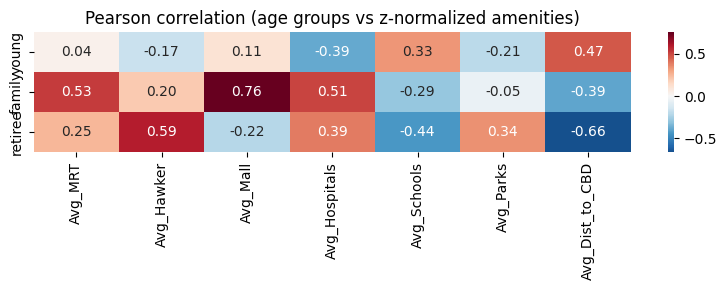

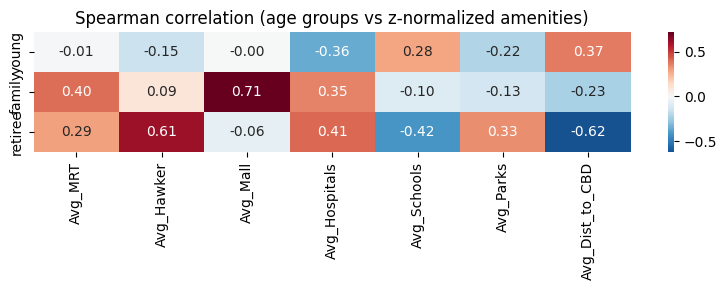

In [12]:
# Cell 9: Heatmaps for quick visual inspection (Spearman & Pearson)
plt.figure(figsize=(8,3))
sns.heatmap(pearson_df.astype(float).T, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Pearson correlation (age groups vs z-normalized amenities)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,3))
sns.heatmap(spearman_df.astype(float).T, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Spearman correlation (age groups vs z-normalized amenities)")
plt.tight_layout()
plt.show()


Softmax weights:


,Avg_MRT,Avg_Hawker,Avg_Mall,Avg_Hospitals,Avg_Schools,Avg_Parks,Avg_Dist_to_CBD
young,0.1338,0.1079,0.1353,0.0792,0.2080,0.0983,0.2376
family,0.1819,0.1149,0.2932,0.1699,0.0867,0.0826,0.0709
retiree,0.1658,0.2665,0.0969,0.1971,0.0569,0.1748,0.0420


Saved heatmap to: age_group_outputs/softmax_correlation_heatmap.png


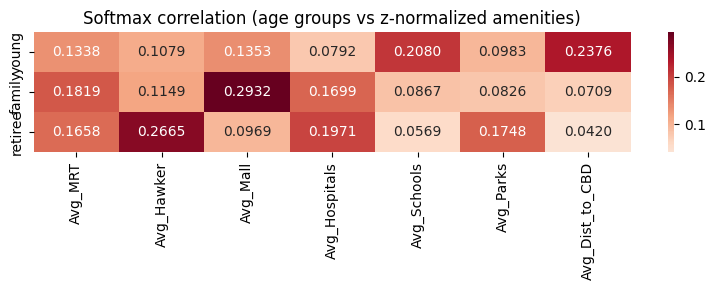

In [14]:
# Softmax weighting (keeps negative information)
alpha = 1.5 

corrs = spearman_df.copy()
exp_vals = np.exp(alpha * corrs)
weights_softmax = exp_vals.div(exp_vals.sum(axis=0), axis=1)

print("Softmax weights:")
display(weights_softmax.T.round(4))

plt.figure(figsize=(8,3))
sns.heatmap(weights_softmax.astype(float).T, annot=True, cmap="RdBu_r", center=0, fmt=".4f")
plt.title("Softmax correlation (age groups vs z-normalized amenities)")
plt.tight_layout()
plt.savefig("age_group_outputs/softmax_correlation_heatmap.png", dpi=300, bbox_inches='tight')
print(f"Saved heatmap to: age_group_outputs/softmax_correlation_heatmap.png")
plt.show()


## Combine Datasets

In [3]:
# Combine all district CSVs into one master dataset
df = pd.concat([
    pd.read_csv('../datasets/updated_coordinates/district1.csv'),
    pd.read_csv('../datasets/updated_coordinates/district2.csv'),
    pd.read_csv('../datasets/updated_coordinates/district3.csv'),
    pd.read_csv('../datasets/updated_coordinates/district4.csv'),
    pd.read_csv('../datasets/updated_coordinates/district5.csv'),
    pd.read_csv('../datasets/updated_coordinates/district6.csv'),
    pd.read_csv('../datasets/updated_coordinates/district7.csv'),
    pd.read_csv('../datasets/updated_coordinates/district8.csv'),
    pd.read_csv('../datasets/updated_coordinates/district9.csv'),
    pd.read_csv('../datasets/updated_coordinates/district10.csv'),
    pd.read_csv('../datasets/updated_coordinates/district11.csv'),
    pd.read_csv('../datasets/updated_coordinates/district12.csv'),
    pd.read_csv('../datasets/updated_coordinates/district13.csv'),
    pd.read_csv('../datasets/updated_coordinates/district14.csv'),
    pd.read_csv('../datasets/updated_coordinates/district15.csv'),
    pd.read_csv('../datasets/updated_coordinates/district16.csv'),
    pd.read_csv('../datasets/updated_coordinates/district17.csv'),
    pd.read_csv('../datasets/updated_coordinates/district18.csv'),
    pd.read_csv('../datasets/updated_coordinates/district19.csv'),
    pd.read_csv('../datasets/updated_coordinates/district20.csv'),
    pd.read_csv('../datasets/updated_coordinates/district21.csv'),
    pd.read_csv('../datasets/updated_coordinates/district22.csv'),
    pd.read_csv('../datasets/updated_coordinates/district23.csv'),
    pd.read_csv('../datasets/updated_coordinates/district25.csv'),
    pd.read_csv('../datasets/updated_coordinates/district26.csv'),
    pd.read_csv('../datasets/updated_coordinates/district27.csv'),
    pd.read_csv('../datasets/updated_coordinates/district28.csv')
], ignore_index=True)

df.drop_duplicates(inplace=True)
df.to_csv('../datasets/updated_coordinates/combined_updated.csv', index=False)

In [5]:
df.shape

(104749, 27)

In [7]:
df

,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale Date,Street Name,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,Latitude,Longitude,Full Address,Nearest MRT Stations,Nearby Hawker Centers,Shopping Malls Within Radius of 1km,Hospitals Within Radius of 5km,Schools Within Radius of 2km,Parks Within Radius of 1km,Dist to CBD in Km
0,ONE MARINA GARDENS,"1,883,403",656.6,"2,868",Sep-25,MARINA GARDENS LANE,New Sale,Strata,61,"30,875",...,1.2758,103.8629,1 MARINA GARDENS LANE ONE MARINA GARDENS (U/C)...,MARINA SOUTH MRT STATION; MARINA SOUTH PIER MR...,NaN,NaN,Changi General Hospital; KK Women's and Childr...,NaN,NaN,1.5487
1,ONE MARINA GARDENS,"2,055,683",656.6,"3,131",Sep-25,MARINA GARDENS LANE,New Sale,Strata,61,"33,700",...,1.2758,103.8629,1 MARINA GARDENS LANE ONE MARINA GARDENS (U/C)...,MARINA SOUTH MRT STATION; MARINA SOUTH PIER MR...,NaN,NaN,Changi General Hospital; KK Women's and Childr...,NaN,NaN,1.5487
2,MARINA BAY RESIDENCES,"1,755,000",731.95,"2,398",Sep-25,MARINA BOULEVARD,Resale,Strata,68,"25,809",...,1.2796,103.8550,18 MARINA BOULEVARD MARINA BAY RESIDENCES SING...,DOWNTOWN MRT STATION; MARINA BAY MRT STATION; ...,Amoy Street Food Centre (Telok Ayer Food Centr...,Marina Bay Sands; The Shoppes at Marina Bay Sa...,Changi General Hospital; KK Women's and Childr...,CANTONMENT PRIMARY SCHOOL; TAO NAN SCHOOL,MARKET STREET PARK; EMPRESS PLACE; RAFFLES PLA...,0.5798
3,ONE MARINA GARDENS,"2,038,262",667.37,"3,054",Sep-25,MARINA GARDENS LANE,New Sale,Strata,62,"32,875",...,1.2758,103.8629,1 MARINA GARDENS LANE ONE MARINA GARDENS (U/C)...,MARINA SOUTH MRT STATION; MARINA SOUTH PIER MR...,NaN,NaN,Changi General Hospital; KK Women's and Childr...,NaN,NaN,1.5487
4,MARINA ONE RESIDENCES,"4,260,000","2,249.68","1,894",Sep-25,MARINA WAY,Resale,Strata,209,"20,383",...,1.2772,103.8537,23 MARINA WAY MARINA ONE RESIDENCES SINGAPORE ...,MARINA BAY MRT STATION; MARINA BAY MRT STATION...,Amoy Street Food Centre (Telok Ayer Food Centr...,The Shoppes at Marina Bay Sands; Marina Bay Li...,Changi General Hospital; KK Women's and Childr...,CANTONMENT PRIMARY SCHOOL; TAO NAN SCHOOL,MARKET STREET PARK; RAFFLES PLACE PK; TELOK AY...,0.7056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108728,RIVERTREES RESIDENCES,"790,000",721.19,"1,095",Nov-20,FERNVALE CLOSE,Resale,Strata,67.0000,"11,791",...,1.3941,103.8808,23 FERNVALE CLOSE RIVERTREES RESIDENCES SINGAP...,LAYAR LRT STATION; KUPANG LRT STATION; FERNVAL...,Fernvale Hawker Centre & Market; Anchorvale Vi...,The Seletar Mall,Sengkang General Hospital; Sengkang Community ...,ANCHOR GREEN PRIMARY SCHOOL; COMPASSVALE PRIMA...,SENGKANG RIVERSIDE PK; LORONG TANGGAM PK; FERN...,12.7265
108729,SUNRISE GARDENS,"795,000","1,033.34",769,Nov-20,SUNRISE AVENUE,Resale,Strata,96.0000,"8,281",...,1.3897,103.8572,53 SUNRISE AVENUE SUNRISE GARDENS SINGAPORE 80...,NaN,NaN,NaN,Sengkang General Hospital; Khoo Teck Puat Hosp...,ANDERSON PRIMARY SCHOOL; ANDERSON SECONDARY SC...,SUNRISE CLOSE PG; SUNRISE DR PG I; SUNRISE PLA...,11.8173
108730,HIGH PARK RESIDENCES,"755,000",592.02,"1,275",Nov-20,FERNVALE ROAD,Resale,Strata,55.0000,"13,727",...,1.3953,103.8745,31 FERNVALE ROAD HIGH PARK RESIDENCES SINGAPOR...,THANGGAM LRT STATION; FERNVALE LRT STATION; LA...,Fernvale Hawker Centre & Market,The Seletar Mall,Sengkang General Hospital; Sengkang Community ...,ANCHOR GREEN PRIMARY SCHOOL; FERN GREEN PRIMAR...,DEW GARDEN; LORONG TANGGAM PK; FERNVALE PARK; ...,12.6931
108731,H2O RESIDENCES,"1,550,000","1,593.07",973,Nov-20,FERNVALE LINK,Resale,Strata,148.0000,"10,473",...,1.3925,103.8806,38 FERNVALE LINK H2O RESIDENCES SINGAPORE 797534,LAYAR LRT STATION; FERNVALE LRT STATION; KUPAN...,Fernvale Hawker Centre & Market; Anchorvale Vi...,Buangkok Square; The Seletar Mall,Sengkang General Hospital; Sengkang Community ...,ANCHOR GREEN PRIMARY SCHOOL; COMPASSVALE PRIMA...,MUGLISTON PK PG; SENGKANG RIVERSIDE PK; FERNVA...,12.5508


## Import ML Libraries

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [9]:
def count_items(x):
    if pd.isna(x):
        return 0
    return len(str(x).split(";"))

df["num_mrt"] = df["Nearest MRT Stations"].apply(count_items)
df["num_hawkers"] = df["Nearby Hawker Centers"].apply(count_items)
df["num_malls"] = df["Shopping Malls Within Radius of 1km"].apply(count_items)
df["num_hospitals"] = df["Hospitals Within Radius of 5km"].apply(count_items)
df["num_schools"] = df["Schools Within Radius of 2km"].apply(count_items)
df["num_parks"] = df["Parks Within Radius of 1km"].apply(count_items)
df["dist_cbd"] = df["Dist to CBD in Km"]


In [10]:
df["Transacted Price ($)"] = (
    df["Transacted Price ($)"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)


In [11]:
weights = {
    "young": {
        "dist_cbd": 0.2376,
        "num_mrt": 0.1338,
        "num_hawkers": 0.1019,
        "num_malls": 0.1353,
        "num_hospitals": 0.0792,
        "num_schools": 0.2080,
        "num_parks": 0.0983
    },
    "families": {
        "dist_cbd": 0.0709,
        "num_mrt": 0.1819,
        "num_hawkers": 0.1149,
        "num_malls": 0.2932,
        "num_hospitals": 0.1699,
        "num_schools": 0.0867,
        "num_parks": 0.0826
    },
    "retirees": {
        "dist_cbd": 0.0420,
        "num_mrt": 0.1658,
        "num_hawkers": 0.2665,
        "num_malls": 0.0969,
        "num_hospitals": 0.1971,
        "num_schools": 0.0569,
        "num_parks": 0.1748
    }
}


In [13]:
median_income_df = pd.read_csv('../datasets/supplementary_datasets/median_income_by_age_group.csv')
median_income_df

,Age Group,Total in Dollars
0,Total,5500
1,15 - 19,1170
2,20 - 24,3269
3,25 - 29,4680
4,30 - 34,5870
5,35 - 39,7049
6,40 - 44,7434
7,45 - 49,7498
8,50 - 54,6400
9,55 - 59,4731


In [14]:
import numpy as np

avg_ya = (1170 + 3269 + 4680 + 5870) / 4
avg_fam = (7049 + 7434 + 7498 + 6400 + 4731) / 5
avg_ret = 3052

age_group_median_income = {
    "young": avg_ya,
    "families": avg_fam,
    "retirees": avg_ret
}

alpha = 0.4

incomes = np.array(list(age_group_median_income.values()))

# --- STEP 1: min-max scale incomes ---
min_i = incomes.min()
max_i = incomes.max()

scaled = (incomes - min_i) / (max_i - min_i)

# --- STEP 2: apply softmax on scaled values ---
shifted = scaled - np.max(scaled)
exp_vals = np.exp(alpha * shifted)
softmax_weights = exp_vals / np.sum(exp_vals)

affordability_weight_softmax = {
    age: w for age, w in zip(age_group_median_income.keys(), softmax_weights)
}

print(affordability_weight_softmax)


{'young': 0.30256254564130514, 'families': 0.417547197624792, 'retirees': 0.2798902567339027}


In [15]:
df.columns

Index(['Project Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale Date', 'Street Name', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Postal District',
       'Market Segment', 'Floor Level', 'Latitude', 'Longitude',
       'Full Address', 'Nearest MRT Stations', 'Nearby Hawker Centers',
       'Shopping Malls Within Radius of 1km', 'Hospitals Within Radius of 5km',
       'Schools Within Radius of 2km', 'Parks Within Radius of 1km',
       'Dist to CBD in Km', 'num_mrt', 'num_hawkers', 'num_malls',
       'num_hospitals', 'num_schools', 'num_parks', 'dist_cbd'],
      dtype='object')

### Building filtered

In [21]:
INPUT_CSV = "../datasets/updated_coordinates/combined_updated.csv"
OUTPUT_DIR = "age_group_outputs/"
TOP_N = 20
MAX_PROPERTIES_PER_BUILDING = 1 

AGE_WEIGHTS = {
    'young': {
        'dist_to_cbd': 0.2376,
        'Num_MRT_With_1km': 0.1338,
        'Num_Hawker_Within_1km': 0.1019,
        'Num_Malls_Within_1km': 0.1353,
        'Num_Hospitals_Within_5km': 0.0792,
        'Num_Schools_Within_2km': 0.2080,
        'Num_Parks_Within_1km': 0.0983
    },
    'family': {
        'dist_to_cbd': 0.0709,
        'Num_MRT_With_1km': 0.1819,
        'Num_Hawker_Within_1km': 0.1149,
        'Num_Malls_Within_1km': 0.2932,
        'Num_Hospitals_Within_5km': 0.1699,
        'Num_Schools_Within_2km': 0.0867,
        'Num_Parks_Within_1km': 0.0826
    },
    'retiree': {
        'dist_to_cbd': 0.0420,
        'Num_MRT_With_1km': 0.1658,
        'Num_Hawker_Within_1km': 0.2665,
        'Num_Malls_Within_1km': 0.0969,
        'Num_Hospitals_Within_5km': 0.1971,
        'Num_Schools_Within_2km': 0.0569,
        'Num_Parks_Within_1km': 0.1748
    }
}

AFFORDABILITY_WEIGHTS = {
    'young': 0.30256254564130514, 
    'family': 0.417547197624792, 
    'retiree': 0.2798902567339027
}

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def count_semicolon_separated(x):
    if pd.isna(x):
        return 0
    s = str(x).strip()
    if not s:
        return 0
    try:
        return max(0, int(float(s)))
    except ValueError:
        pass
    parts = [p.strip() for p in s.replace(',', ';').split(';') if p.strip()]
    return len(parts)

def robust_minmax_norm(series):
    s = pd.to_numeric(series, errors='coerce')
    vmin, vmax = s.min(skipna=True), s.max(skipna=True)
    
    if pd.isna(vmin) or pd.isna(vmax) or vmax == vmin:
        return pd.Series(0.0, index=s.index)
    
    normalized = (s - vmin) / (vmax - vmin)
    return normalized.fillna(0.0).clip(0.0, 1.0)

def find_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

def get_diverse_top_n(df, score_col, top_n, max_per_building=1):
    result = []
    building_counts = {}
    
    df_sorted = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    
    for idx, row in df_sorted.iterrows():
        building_name = row.get('Project Name', '')
        
        # Count how many properties from this building we've already added
        current_count = building_counts.get(building_name, 0)
        
        if current_count < max_per_building:
            result.append(row)
            building_counts[building_name] = current_count + 1
        if len(result) >= top_n:
            break
    
    return pd.DataFrame(result)

def prepare_and_score(input_csv, output_dir, top_n=10, max_per_building=1):
    ensure_dir(output_dir)
    
    if not os.path.exists(input_csv):
        raise FileNotFoundError(f"Input CSV not found: {input_csv}")
    
    df = pd.read_csv(input_csv)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"✓ Loaded {len(df):,} rows from {input_csv}")
    
    amenity_mappings = {
        'Num_MRT_With_1km': [
            'Nearest MRT Stations', 'Nearest_MRT_Stations', 
            'Num MRT Within 1km', 'Num_MRT_With_1km'
        ],
        'Num_Hawker_Within_1km': [
            'Nearby Hawker Centers', 'Nearby_Hawker_Centers',
            'Num Hawker Within 1km', 'Num_Hawker_Within_1km'
        ],
        'Num_Malls_Within_1km': [
            'Shopping Malls Within Radius of 1km', 'Shopping Malls Within 1km',
            'Num Malls Within 1km', 'Num_Malls_Within_1km'
        ],
        'Num_Hospitals_Within_5km': [
            'Hospitals Within Radius of 5km', 'Hospitals Within 5km',
            'Num Hospitals Within 5km', 'Num_Hospitals_Within_5km'
        ],
        'Num_Schools_Within_2km': [
            'Schools Within Radius of 2km', 'Schools Within 2km',
            'Num Schools Within 2km', 'Num_Schools_Within_2km'
        ],
        'Num_Parks_Within_1km': [
            'Parks Within Radius of 1km', 'Parks Within 1km',
            'Num Parks Within 1km', 'Num_Parks_Within_1km'
        ]
    }
    
    for target_col, candidates in amenity_mappings.items():
        source_col = find_column(df, candidates)
        if source_col:
            if pd.api.types.is_numeric_dtype(df[source_col]):
                df[target_col] = pd.to_numeric(df[source_col], errors='coerce').fillna(0).astype(int)
            else:
                df[target_col] = df[source_col].apply(count_semicolon_separated)
        else:
            df[target_col] = 0
            print(f"⚠ Warning: No source found for {target_col}, using 0")
    
    dist_candidates = ['Dist to CBD in Km', 'Dist to CBD (Km)', 'Dist_to_CBD_km', 'dist_to_cbd']
    dist_col = find_column(df, dist_candidates)
    if dist_col:
        df['dist_to_cbd'] = pd.to_numeric(df[dist_col], errors='coerce')
    else:
        df['dist_to_cbd'] = np.nan
        print("⚠ Warning: No distance to CBD column found")
    
    if 'Postal District' in df.columns:
        df['Postal District'] = df['Postal District'].astype(str)
    else:
        df['Postal District'] = ''
    
    if 'Area (SQM)' not in df.columns and 'Area (SQFT)' in df.columns:
        df['Area (SQM)'] = pd.to_numeric(df['Area (SQFT)'], errors='coerce') * 0.092903
    elif 'Area (SQM)' not in df.columns:
        df['Area (SQM)'] = np.nan
    
    if 'Unit Price ($ PSM)' in df.columns:
        if pd.api.types.is_numeric_dtype(df['Unit Price ($ PSM)']):
            df['unit_price_psm'] = pd.to_numeric(df['Unit Price ($ PSM)'], errors='coerce')
        else:
            price_psm_clean = df['Unit Price ($ PSM)'].astype(str).str.replace(',', '').str.replace('$', '').str.strip()
            df['unit_price_psm'] = pd.to_numeric(price_psm_clean, errors='coerce')
    elif 'Unit Price ($ PSF)' in df.columns:
        if pd.api.types.is_numeric_dtype(df['Unit Price ($ PSF)']):
            df['unit_price_psm'] = pd.to_numeric(df['Unit Price ($ PSF)'], errors='coerce') * 10.7639
        else:
            price_psf_clean = df['Unit Price ($ PSF)'].astype(str).str.replace(',', '').str.replace('$', '').str.strip()
            df['unit_price_psm'] = pd.to_numeric(price_psf_clean, errors='coerce') * 10.7639
    else:
        price_candidates = ['Transacted Price ($)', 'Transacted Price', 'Price ($)', 'Price']
        price_col = find_column(df, price_candidates)
        
        if price_col is not None:
            price_clean = df[price_col].astype(str).str.replace(',', '').str.replace('$', '').str.strip()
            price_clean = pd.to_numeric(price_clean, errors='coerce')
            
            area_clean = pd.to_numeric(df['Area (SQM)'], errors='coerce')
            
            df['unit_price_psm'] = price_clean / area_clean.replace(0, np.nan)
        else:
            df['unit_price_psm'] = np.nan
            print("⚠ Warning: No price column found for unit_price_psm calculation")

    df['unit_price_psm'] = df['unit_price_psm'].replace([np.inf, -np.inf], np.nan)

    valid_prices = df['unit_price_psm'].notna().sum()
    print(f"✓ Valid unit_price_psm values: {valid_prices:,} / {len(df):,}")
    
    print("\n✓ Normalizing features...")
    
    amenity_cols = [
        'Num_MRT_With_1km', 'Num_Hawker_Within_1km', 'Num_Malls_Within_1km',
        'Num_Hospitals_Within_5km', 'Num_Schools_Within_2km', 'Num_Parks_Within_1km'
    ]
    
    for col in amenity_cols:
        df[f'{col}_norm'] = robust_minmax_norm(df[col])
    
    df['dist_to_cbd_norm'] = robust_minmax_norm(df['dist_to_cbd'])
    df['dist_proximity_norm'] = 1.0 - df['dist_to_cbd_norm']
    df['unit_price_psm_norm'] = robust_minmax_norm(df['unit_price_psm'])

    # store each age group affordability separately
    for age_group, w in AFFORDABILITY_WEIGHTS.items():
        df[f'affordability_{age_group}'] = (1.0 - df['unit_price_psm_norm'] * (1 / w))
    
    print("\n✓ Computing age-group scores...")
    
    feature_to_norm_col = {
        'dist_to_cbd': 'dist_proximity_norm',
        'Num_MRT_With_1km': 'Num_MRT_With_1km_norm',
        'Num_Hawker_Within_1km': 'Num_Hawker_Within_1km_norm',
        'Num_Malls_Within_1km': 'Num_Malls_Within_1km_norm',
        'Num_Hospitals_Within_5km': 'Num_Hospitals_Within_5km_norm',
        'Num_Schools_Within_2km': 'Num_Schools_Within_2km_norm',
        'Num_Parks_Within_1km': 'Num_Parks_Within_1km_norm'
    }
    
    for age_group, weights in AGE_WEIGHTS.items():

        # Amenity score
        amenity_score = np.zeros(len(df))
        for feature, weight in weights.items():
            norm_col = feature_to_norm_col.get(feature)
            if norm_col in df.columns:
                amenity_score += weight * df[norm_col].values

        df[f'score_property_{age_group}'] = amenity_score

        df[f'worth_{age_group}'] = round(100 * ((amenity_score + df[f'affordability_{age_group}']) / 2), 2)    
    
    df['has_all_amenities'] = (
        (df['Num_MRT_With_1km'] + df['Num_Hawker_Within_1km'] + 
         df['Num_Malls_Within_1km'] + df['Num_Hospitals_Within_5km'] + 
         df['Num_Schools_Within_2km'] + df['Num_Parks_Within_1km']) > 0
    ).astype(int)
    
    df['has_price_data'] = df['unit_price_psm'].notna().astype(int)
    
    combined_out = os.path.join(output_dir, "combined_property_scores.csv")
    df.to_csv(combined_out, index=False)
    print(f"\nSaved combined property-level CSV: {combined_out}")
    
    for age_group in AGE_WEIGHTS.keys():
        display_cols = [
            'Project Name', 'Postal District', 'Transacted Price ($)', 'Area (SQM)', 'unit_price_psm',
            'dist_to_cbd', 'dist_proximity_norm', f'score_property_{age_group}', 
            f'affordability_{age_group}', f'worth_{age_group}'
        ]
        display_cols = [c for c in display_cols if c in df.columns]
        
        valid_df = df[df['has_all_amenities'] == 1].copy()
        top_df = get_diverse_top_n(
            valid_df, 
            f'worth_{age_group}', 
            top_n, 
            max_per_building
        )[display_cols]
        
        out_file = os.path.join(output_dir, f"top{top_n}_{age_group}.csv")
        top_df.to_csv(out_file, index=False)
        
        print(f"\nTop {top_n} properties for '{age_group}' (max {max_per_building} per building):")
        print(top_df.to_string(index=False))
    
    return top_df, df

# ========== EXECUTE ==========
if __name__ == "__main__":
    df_top, df_result = prepare_and_score(
        INPUT_CSV, 
        OUTPUT_DIR, 
        top_n=TOP_N,
        max_per_building=MAX_PROPERTIES_PER_BUILDING
    )

/var/folders/g_/fmz6fbfx0l96hfjsv2764ypw0000gn/T/ipykernel_69416/2696703615.py:100: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


✓ Loaded 104,749 rows from ../datasets/updated_coordinates/combined_updated.csv
✓ Valid unit_price_psm values: 104,749 / 104,749

✓ Normalizing features...

✓ Computing age-group scores...

Saved combined property-level CSV: age_group_outputs/combined_property_scores.csv

Top 20 properties for 'young' (max 1 per building):
                  Project Name Postal District Transacted Price ($) Area (SQM)  unit_price_psm  dist_to_cbd  dist_proximity_norm  score_property_young  affordability_young  worth_young
         PEOPLE'S PARK COMPLEX               1              700,000        104            6731       0.9521               0.9647                0.6449               0.8163      73.0600
          PEOPLE'S PARK CENTRE               1            1,750,000        217            8065       0.8392               0.9705                0.6170               0.7514      68.4200
                 WATERLOO VIEW               7            1,600,000        165            9697       1.9735             

In [22]:
young_top_df = pd.read_csv('age_group_outputs/top20_young.csv')
family_top_df = pd.read_csv('age_group_outputs/top20_family.csv')
retiree_top_df = pd.read_csv('age_group_outputs/top20_retiree.csv')


In [23]:
young_top_df

,Project Name,Postal District,Transacted Price ($),Area (SQM),unit_price_psm,dist_to_cbd,dist_proximity_norm,score_property_young,affordability_young,worth_young
0,PEOPLE'S PARK COMPLEX,1,"700,000",104.0000,6731,0.9521,0.9647,0.6449,0.8163,73.0600
1,PEOPLE'S PARK CENTRE,1,"1,750,000",217.0000,8065,0.8392,0.9705,0.6170,0.7514,68.4200
2,WATERLOO VIEW,7,"1,600,000",165.0000,9697,1.9735,0.9123,0.6364,0.6721,65.4300
3,BEDOK SHOPPING COMPLEX,16,"340,000",113.0000,3009,12.0375,0.3964,0.2797,0.9971,63.8400
4,SUN COURT,21,"492,633",167.0000,2950,10.7709,0.4613,0.2532,1.0000,62.6600
5,KIM KEAT GARDENS,12,"1,600,000",240.0000,6667,4.4917,0.7832,0.4262,0.8194,62.2800
6,JIA,9,"3,100,000",299.0000,10368,2.1846,0.9015,0.5945,0.6395,61.7000
7,PUBLIC MANSION,12,"1,880,000",235.0000,8000,4.8063,0.7671,0.4747,0.7546,61.4700
8,HONG BUILDING,8,"1,422,850",127.0000,11204,1.7953,0.9215,0.6282,0.5989,61.3500
9,RACE COURSE 138,8,"980,000",112.0000,8750,2.9690,0.8613,0.5014,0.7182,60.9800


In [47]:
family_top_df

,Project Name,Postal District,Transacted Price ($),Area (SQM),unit_price_psm,dist_to_cbd,dist_proximity_norm,score_property_family,affordability_family,worth_family
0,PEOPLE'S PARK COMPLEX,1.0,"700,000",104.0,6731,0.952050,0.964691,0.605874,0.866862,73.64
1,WATERLOO VIEW,7.0,"1,600,000",165.0,9697,1.973531,0.912326,0.681452,0.762422,72.19
2,HONG BUILDING,8.0,"1,422,850",127.0,11204,1.795329,0.921461,0.692715,0.709357,70.10
3,PEOPLE'S PARK CENTRE,1.0,"1,750,000",217.0,8065,0.839154,0.970479,0.576039,0.819888,69.80
4,JIA,9.0,"3,100,000",299.0,10368,2.184583,0.901506,0.618393,0.738794,67.86
5,SUNSHINE PLAZA,7.0,"1,448,800",121.0,11974,1.918217,0.915161,0.651859,0.682243,66.71
6,8 @ MOUNT SOPHIA,9.0,"2,600,000",232.0,11207,2.064235,0.907676,0.607063,0.709251,65.82
7,ESPA,23.0,"1,600,000",156.0,10256,2.243435,0.898489,0.567307,0.742738,65.50
8,SOPHIA RESIDENCE,9.0,"2,770,000",239.0,11590,2.073207,0.907216,0.607955,0.695765,65.19
9,SEASONS PARK,26.0,"1,100,000",134.0,8209,3.362371,0.841128,0.484516,0.814818,64.97


In [48]:
retiree_top_df

,Project Name,Postal District,Transacted Price ($),Area (SQM),unit_price_psm,dist_to_cbd,dist_proximity_norm,score_property_retiree,affordability_retiree,worth_retiree
0,PEOPLE'S PARK COMPLEX,1.0,"700,000",104.0,6731,0.952050,0.964691,0.757353,0.801381,77.94
1,PEOPLE'S PARK CENTRE,1.0,"1,750,000",217.0,8065,0.839154,0.970479,0.710544,0.731305,72.09
2,WATERLOO VIEW,7.0,"1,600,000",165.0,9697,1.973531,0.912326,0.629044,0.645575,63.73
3,SUN COURT,21.0,"492,633",167.0,2950,10.770862,0.461335,0.255509,1.000000,62.78
4,BEDOK SHOPPING COMPLEX,16.0,"340,000",113.0,3009,12.039979,0.396275,0.198107,0.996901,59.75
5,RACE COURSE 138,8.0,"980,000",112.0,8750,2.969008,0.861293,0.495531,0.695321,59.54
6,JIA,9.0,"3,100,000",299.0,10368,2.184583,0.901506,0.565896,0.610327,58.81
7,HONG BUILDING,8.0,"1,422,850",127.0,11204,1.795329,0.921461,0.599247,0.566411,58.28
8,RACE COURSE MANSION,8.0,"1,080,000",117.0,9231,2.938674,0.862848,0.493700,0.670054,58.19
9,LITTLE INDIA CONSERVATION AREA,8.0,"1,050,000",107.0,9813,2.410502,0.889925,0.520180,0.639481,57.98
